# Step-1> Problem Statement: Predicition of Sales

Rossmann operates over 3,000 drug stores in 7 European countries. Currently, Rossmann store managers are tasked with predicting their daily sales for up to six weeks in advance. Store sales are influenced by many factors, including promotions, competition, school and state holidays, seasonality, and locality. With thousands of individual managers predicting sales based on their unique circumstances, the accuracy of results can be quite varied.

The first step in any machine learning problem is to read the given documentation, talk to various stakeholders and identify the following:

1. What is the business problem you're trying to solve using machine learning?
2. Why are we interested in solving this problem? What impact will it have on the business?
3. How is this problem solved currently, without any machine learning tools?
4. Who will use the results of this model, and how does it fit into other business processes?
5. How much historical data do we have, and how was it collected?
6. What features does the historical data contain? Does it contain the historical values for what we're trying to predict.
7. What are some known issues with the data (data entry errors, missing data, differences in units etc.)
8. Can we look at some sample rows from the dataset? How representative are they of the entire dataset.
9. Where is the data stored and how will you get access to it?
10. ...

Gather as much information about the problem as possible, so that you're clear understanding of the objective and feasibility of the project.

In [1]:
#%pip install opendatasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import opendatasets


##changing the scintific output of the pandas:
#     1)  pd.set_option('display.float_format', '{:.0f}'.format) #Disable scientific notation globally
#     2)  pd.set_option('display.float_format', '{:.2f}'.format) #Keep decimals but remove scientific notation
#     3) merged_df.describe().map(lambda x: f"{x:,.0f}")  #Only for spedific output (temporary)

#pd.set_option('display.float_format', '{:3f}'.format) not good

imporitng the data from kaggle

API KEY: KGAT_06e52b30bb2e2f9011f8bf473efe4f1b

HOW TO IMPORT:

export KAGGLE_API_TOKEN=KGAT_ef8feb3f15f129aaad3eb1b1a174c2f8

In [3]:
#opendatasets.download('https://www.kaggle.com/c/rossmann-store-sales')
#opendatasets.download_kaggle_dataset('https://www.kaggle.com/c/rossmann-store-sales', data_dir=os.curdir)

# Step-2> is to import and understand the data

In [3]:
ross_df = pd.read_csv(r'train.csv').copy()

C:\Users\itspr\AppData\Local\Temp\ipykernel_21968\1691143083.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  ross_df = pd.read_csv(r'train.csv').copy()


In [5]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [6]:
store_df = pd.read_csv(r'store.csv').copy()

In [7]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [8]:
store_df.head(20)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


In [9]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_df


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [10]:
merged_df.shape

(1017209, 18)

In [11]:
test_df = pd.read_csv(r'test.csv').copy()

In [12]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [13]:
merged_test_df = test_df.merge(store_df, how='left', on='Store')
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


# Step-3> Cleaning Data

The first step is to check the column data types and identify if there are any null values

In [14]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [15]:
########    merged_df.isnull().count()      ###### why wrong reasons:

# 1) merged_df.isnull()
#    → Converts DataFrame values to:
#        True  = value IS null
#        False = value is NOT null

# 2) merged_df.isnull().count()
#    → count() counts NON-NULL values
#    → True / False are NOT null
#    → So every row is counted

#    Result:
#        Total number of rows
#        repeated for each column


In [16]:
merged_df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [17]:
merged_df.describe().map(lambda x: f'{x:}')

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1017209.0,1017209.0,1017209.0,1017209.0,1017209.0,1017209.0,1017209.0,1014567.0,693861.0,693861.0,1017209.0,509178.0,509178.0
mean,558.4297268309659,3.998340557348588,5773.818972305593,633.1459464082602,0.8301066939045958,0.3815145166824124,0.17864666946517382,5430.085652302903,7.222865963067531,2008.6902275816049,0.5005637976069814,23.269092537383784,2011.7527740790058
std,321.9086511434535,1.997390964940531,3849.92617523476,464.4117338866325,0.3755392246931948,0.4857586048774201,0.3830563681809262,7715.323700270178,3.2118321134577426,5.992644443814034,0.499999927902717,14.095972529260496,1.6628704306428779
min,1.0,1.0,0.0,0.0,0.0,0.0,0.0,20.0,1.0,1900.0,0.0,1.0,2009.0
25%,280.0,2.0,3727.0,405.0,1.0,0.0,0.0,710.0,4.0,2006.0,0.0,13.0,2011.0
50%,558.0,4.0,5744.0,609.0,1.0,0.0,0.0,2330.0,8.0,2010.0,1.0,22.0,2012.0
75%,838.0,6.0,7856.0,837.0,1.0,1.0,0.0,6890.0,10.0,2013.0,1.0,37.0,2013.0
max,1115.0,7.0,41551.0,7388.0,1.0,1.0,1.0,75860.0,12.0,2015.0,1.0,50.0,2015.0


In [18]:
#check for duplicate rows also
merged_df.duplicated().sum()

np.int64(0)

In [19]:
#parsing date
merged_df['Date'] = pd.to_datetime(merged_df.Date)
merged_test_df['Date'] = pd.to_datetime(merged_test_df.Date)

In [20]:
merged_df.Date.min(), merged_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [21]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))


# Step-4> Exploratory Data Analysis and Vizualization

**Objectives of exploratory data analysis:**

    1) Study the distribution of individual columns(uniform, normal, exponential)

    2) Detect anomalies or errors in the data(e.g. missing/incorrect values)

    3) Study the relationship of target column with other columns(linear, non-linear etc.)

    4) Gather insights about the problem and the dataset

    5) Come up wit ideas for preprocessing and feature engineering


Study the distribution of the target 'Sales' column

<Axes: xlabel='Sales', ylabel='Count'>

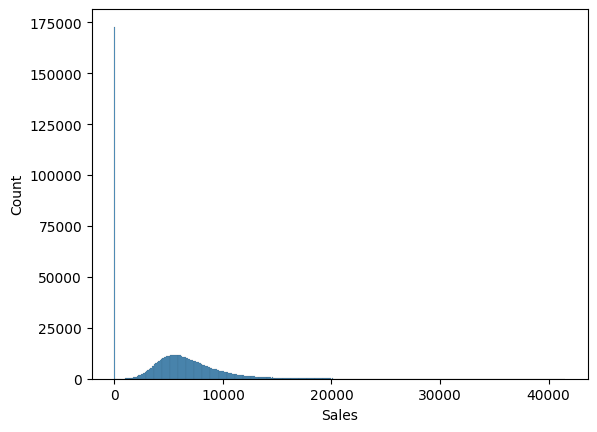

In [22]:
sns.histplot(data=merged_df, x='Sales')

In [23]:
merged_df['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

To make our modeling simple, we are simply excluding the dates when the store was closed (we can handle it as a special case while making predictions)

In [24]:
merged_df = merged_df[merged_df.Open==1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

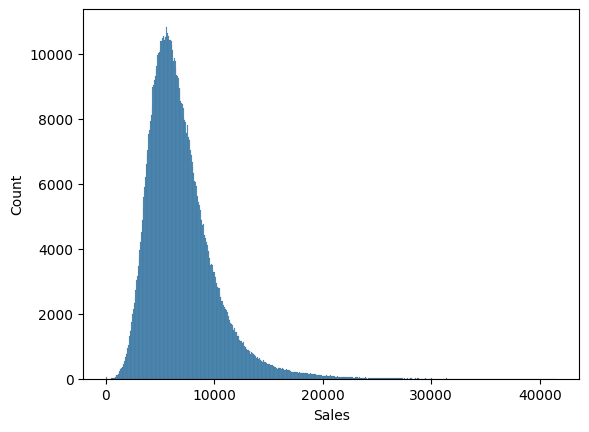

In [25]:
sns.histplot(data=merged_df, x='Sales')

Text(0.5, 1.0, 'Sales Vs Customers')

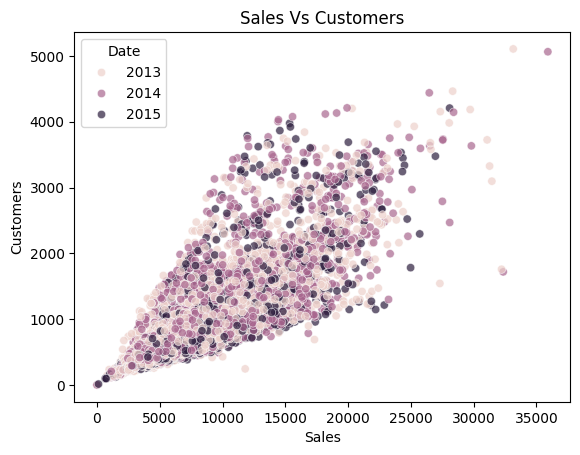

In [26]:
temp_df = merged_df.sample(40000)
sns.scatterplot(data=temp_df, x='Sales', y='Customers', hue=temp_df.Date.dt.year, alpha=0.7)
plt.title('Sales Vs Customers')

In [27]:
px.scatter(temp_df, x='Sales', y='Customers' ,color=temp_df.Date.dt.year, opacity=0.6)

In [28]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')

In [29]:
px.scatter(merged_df.sample(40000), x='Store', y='Sales', color = merged_df.sample(40000).Date.dt.year, opacity=0.4)

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

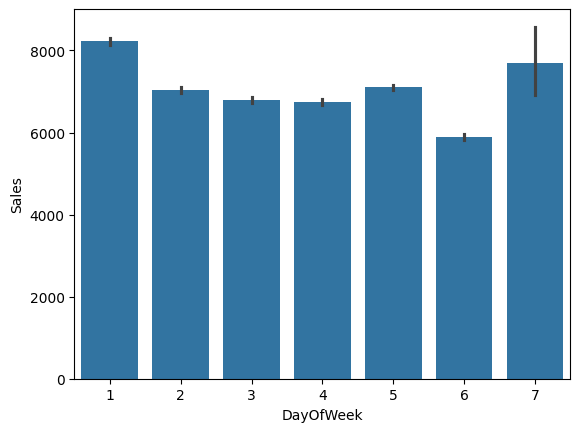

In [30]:
sns.barplot(data=temp_df, x='DayOfWeek', y='Sales')

<Axes: xlabel='Promo', ylabel='Sales'>

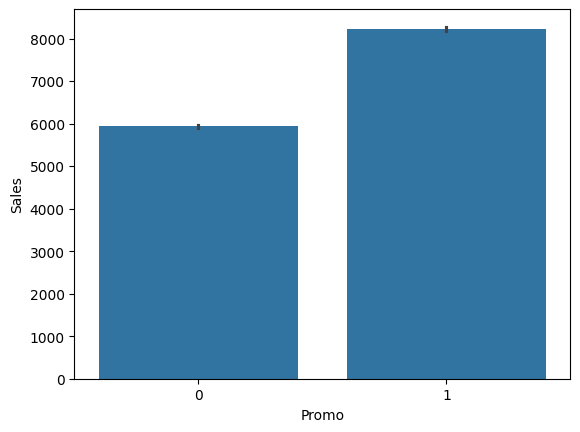

In [31]:
sns.barplot(data=temp_df, x='Promo', y='Sales')

In [32]:
temp_df['Sales']

938344     3715
858177     5977
903721     4617
1006563    6679
686247     5063
           ... 
485088     5926
362092     6233
189953     4738
11978      4422
571107     4939
Name: Sales, Length: 40000, dtype: int64

In [33]:
merged_df.select_dtypes(include='number').corr()['Sales'].sort_values(ascending=False)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Promo2SinceWeek              0.095311
SchoolHoliday                0.038617
CompetitionOpenSinceYear     0.016101
Store                        0.007710
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

<Axes: xlabel='Promo2SinceWeek', ylabel='Sales'>

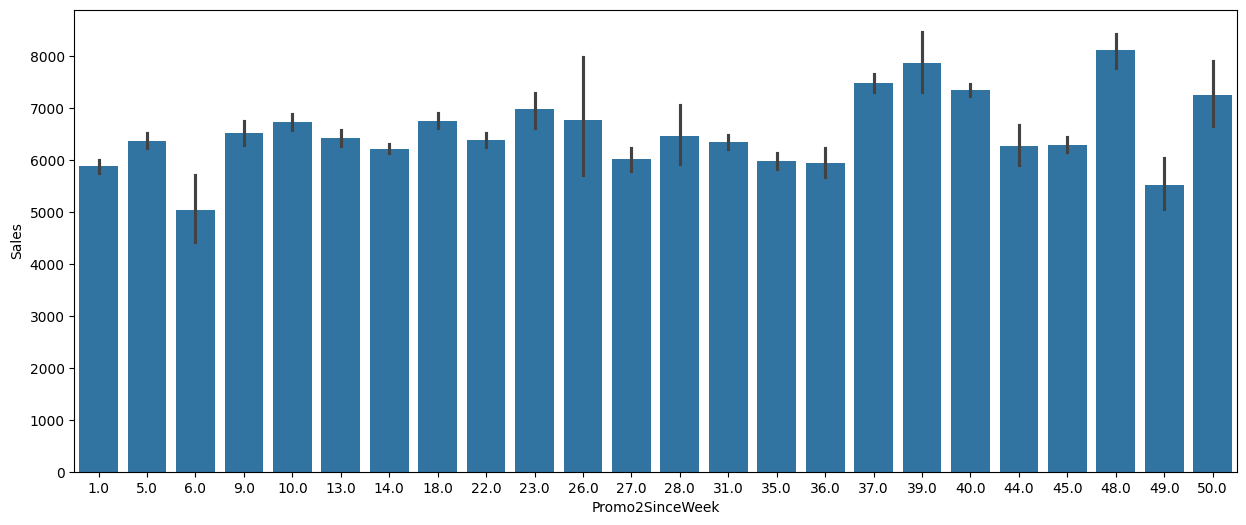

In [34]:
plt.figure(figsize=[15, 6])
sns.barplot(data=temp_df, x='Promo2SinceWeek', y='Sales')

# Step-5> Feature Engineering

Feature engineering is the process of creating new features (columns) by **transforming/combining** existing features or by incorporating data from external sources.

For example, here are some features that can be extracted from the 'Date' column:
1) Day of Week
2) Day or month
3) Month
4) Year
5) Weekend/Weekday
6) Month/Quater End

In [35]:
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

In [36]:
merged_df['Day'] = merged_df.Date.dt.day
merged_df['Month'] = merged_df.Date.dt.month
merged_df['Year'] = merged_df.Date.dt.year

In [37]:
merged_test_df['Day'] = merged_test_df.Date.dt.day
merged_test_df['Month'] = merged_test_df.Date.dt.month
merged_test_df['Year'] = merged_test_df.Date.dt.year

In [38]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Day,Month,Year
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,1270.0,9.0,2008.0,0,NaN,NaN,NaN,31,7,2015
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",31,7,2015
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",31,7,2015
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,620.0,9.0,2009.0,0,NaN,NaN,NaN,31,7,2015
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,29910.0,4.0,2015.0,0,NaN,NaN,NaN,31,7,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1,b,...,150.0,9.0,2006.0,0,NaN,NaN,NaN,1,1,2013
1016827,733,2,2013-01-01,10765,2377,1,0,a,1,b,...,860.0,10.0,1999.0,0,NaN,NaN,NaN,1,1,2013
1016863,769,2,2013-01-01,5035,1248,1,0,a,1,b,...,840.0,NaN,NaN,1,48.0,2012.0,"Jan,Apr,Jul,Oct",1,1,2013
1017042,948,2,2013-01-01,4491,1039,1,0,a,1,b,...,1430.0,NaN,NaN,0,NaN,NaN,NaN,1,1,2013


<Axes: xlabel='Year', ylabel='Sales'>

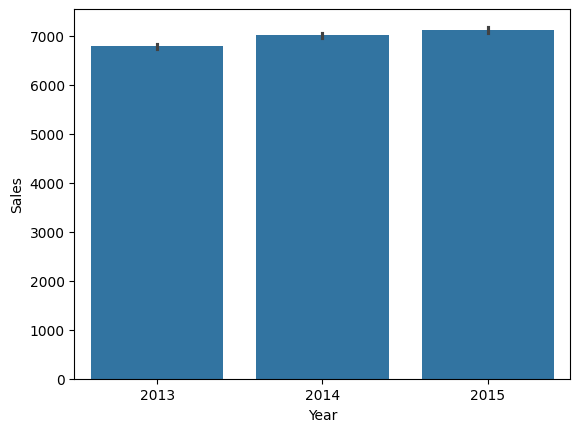

In [39]:
sns.barplot(data=merged_df.sample(40000), x='Year', y='Sales')

<Axes: xlabel='Month', ylabel='Sales'>

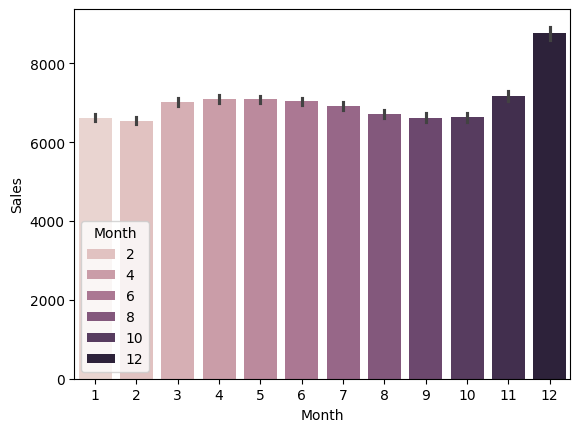

In [40]:
sns.barplot(data=merged_df.sample(40000), x='Month', y='Sales', hue='Month')

<Axes: xlabel='Day', ylabel='Sales'>

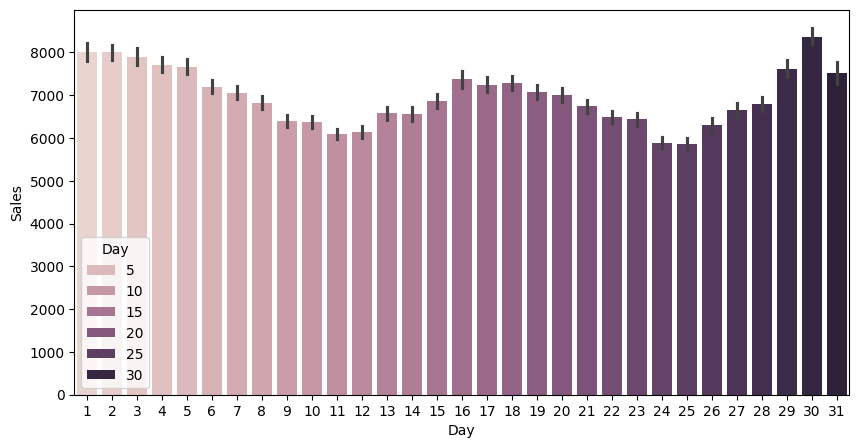

In [41]:
plt.figure(figsize=[10, 5])
sns.barplot(data=merged_df.sample(40000), x='Day', y='Sales', hue='Day')

We can also add some other diffenrent columns but these can be important like:
1) if it rained or not on that day
2) what was the temperature
3) population near the store

these can make a significant impact on our model prediciton.

# Step-6> Creating training/test/validation split and prepare the data for training

# Step-6-A> Train/Test/Validation Split

The data already contains a test set, which contains over one month of data after the end of the training set. We can apply a similar strategy to create a validation set. We'll the last 25% of rows for the validation set, after ordering by date


In [42]:
len(merged_df)

844392

In [43]:
train_size = int(0.75 * len(merged_df))
train_size

633294

In [44]:
sorted_df = merged_df.sort_values('Date')
train_df, val_df = sorted_df[:train_size], sorted_df[train_size:]

In [45]:
len(train_df), len(val_df)

(633294, 211098)

In [46]:
train_df.Date.min(), train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2014-12-10 00:00:00'))

In [47]:
val_df.Date.min(), val_df.Date.max()

(Timestamp('2014-12-10 00:00:00'), Timestamp('2015-07-31 00:00:00'))

# Step-6-B> Separating Input and Target Columns

Let's also identify input and target columns. *Note that we can't use the no. of customers as an input, because this*
information isn't available beforehand. Also, we needn't use all the available columns, we can start out with just a small
subset.

In [48]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year'],
      dtype='object')

In [49]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment', 'Day', 'Month', 'Year']

target_cols = 'Sales'

**Curse of Dimensionality** in machine learning refers to the problem that arises when the number of features increases, causing data to become sparse and distances between data points to lose meaning, which makes learning patterns difficult and reduces model performance.

In my dataset, the *store* feature is a categorical column with **1115 unique values**. When such a feature is encoded (for example, using one-hot encoding), it can create a very high-dimensional feature space, increasing sparsity and computational cost, and potentially leading to overfitting—this is a practical example of the curse of dimensionality.

# Step-6-C> Separating Input & Output Columns

In [50]:
merged_df[input_cols].nunique()

Store           1115
DayOfWeek          7
Promo              2
StateHoliday       5
StoreType          4
Assortment         3
Day               31
Month             12
Year               3
dtype: int64

In [51]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_cols].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_cols].copy()

test_inputs = merged_test_df[input_cols].copy()
#test data does not have targets

Note: Some columns can be treated as both numeric and categorical, and it's up to you how you deal with them

In [52]:
numeric_cols = ['Store', 'Day', 'Month', 'Year']
cat_cols = ['DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment']

In [53]:
train_inputs

,Store,DayOfWeek,Promo,StateHoliday,StoreType,Assortment,Day,Month,Year
1017190,1097,2,0,a,b,b,1,1,2013
1016179,85,2,0,a,b,a,1,1,2013
1016353,259,2,0,a,b,b,1,1,2013
1016356,262,2,0,a,b,a,1,1,2013
1016368,274,2,0,a,b,b,1,1,2013
...,...,...,...,...,...,...,...,...,...
256632,745,3,0,0,a,a,10,12,2014
256642,756,3,0,0,a,c,10,12,2014
256634,747,3,0,0,c,c,10,12,2014
256633,746,3,0,0,d,c,10,12,2014


# Step-7-D> Imputation, Scaling and Encode

Imputing missing data from numeric columns

In [54]:
from sklearn.impute import SimpleImputer

In [55]:
imputer = SimpleImputer(strategy='mean').fit(train_inputs[numeric_cols])

In [56]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

Note that this step wasn't necessary for the store sales dataset, as there were no null values. Also, we can apply a differentimputation strategy to different columns depending on their distributions (e.g. mean for normally distribute and median forexponentially distributed).

# Step-7-E> Scaling the inputs

In [57]:
from sklearn.preprocessing import MinMaxScaler

In [58]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [59]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

In [60]:
train_inputs

,Store,DayOfWeek,Promo,StateHoliday,StoreType,Assortment,Day,Month,Year
1017190,0.983842,2,0,a,b,b,0.0,0.0,0.0
1016179,0.075404,2,0,a,b,a,0.0,0.0,0.0
1016353,0.231598,2,0,a,b,b,0.0,0.0,0.0
1016356,0.234291,2,0,a,b,a,0.0,0.0,0.0
1016368,0.245063,2,0,a,b,b,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
256632,0.667864,3,0,0,a,a,0.3,1.0,1.0
256642,0.677738,3,0,0,a,c,0.3,1.0,1.0
256634,0.669659,3,0,0,c,c,0.3,1.0,1.0
256633,0.668761,3,0,0,d,c,0.3,1.0,1.0


# Step-7-F> Encoding the Categorical Columns

In [61]:
from sklearn.preprocessing import OneHotEncoder

In [62]:
train_df['DayOfWeek']

1017190    2
1016179    2
1016353    2
1016356    2
1016368    2
          ..
256632     3
256642     3
256634     3
256633     3
256636     3
Name: DayOfWeek, Length: 633294, dtype: int64

In [63]:
train_df[cat_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 633294 entries, 1017190 to 256636
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DayOfWeek     633294 non-null  int64 
 1   Promo         633294 non-null  int64 
 2   StateHoliday  633294 non-null  object
 3   StoreType     633294 non-null  object
 4   Assortment    633294 non-null  object
dtypes: int64(2), object(3)
memory usage: 29.0+ MB


In [64]:
for col in cat_cols:
    print(col, train_inputs[col].map(type).value_counts())

DayOfWeek DayOfWeek
<class 'int'>    633294
Name: count, dtype: int64
Promo Promo
<class 'int'>    633294
Name: count, dtype: int64
StateHoliday StateHoliday
<class 'str'>    521154
<class 'int'>    112140
Name: count, dtype: int64
StoreType StoreType
<class 'str'>    633294
Name: count, dtype: int64
Assortment Assortment
<class 'str'>    633294
Name: count, dtype: int64


In [65]:
train_inputs['StateHoliday'] = train_inputs['StateHoliday'].astype(str)
test_inputs['StateHoliday'] = test_inputs['StateHoliday'].astype(str)
val_inputs['StateHoliday'] = val_inputs['StateHoliday'].astype(str)

In [66]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[cat_cols])
encoded_cols = list(encoder.get_feature_names_out(cat_cols))


In [67]:
encoded_cols

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'Promo_0',
 'Promo_1',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

now creating the perfect data which in be direclty fit into the model

In [68]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[cat_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[cat_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[cat_cols])


In [69]:
for col in train_inputs.columns:
    print(col, train_inputs.columns.map(type).value_counts())

Store <class 'str'>    29
Name: count, dtype: int64
DayOfWeek <class 'str'>    29
Name: count, dtype: int64
Promo <class 'str'>    29
Name: count, dtype: int64
StateHoliday <class 'str'>    29
Name: count, dtype: int64
StoreType <class 'str'>    29
Name: count, dtype: int64
Assortment <class 'str'>    29
Name: count, dtype: int64
Day <class 'str'>    29
Name: count, dtype: int64
Month <class 'str'>    29
Name: count, dtype: int64
Year <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_1 <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_2 <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_3 <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_4 <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_5 <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_6 <class 'str'>    29
Name: count, dtype: int64
DayOfWeek_7 <class 'str'>    29
Name: count, dtype: int64
Promo_0 <class 'str'>    29
Name: count, dtype: int64
Promo_1 <class 'str'>    29
Name: count, dtype: int64
S

In [70]:
X_train = train_inputs[numeric_cols+encoded_cols]
X_test = test_inputs[numeric_cols+encoded_cols]
X_val= val_inputs[numeric_cols+encoded_cols]

In [71]:
for col in X_train.columns:
    print(col, X_train[col].map(type).value_counts())

Store Store
<class 'float'>    633294
Name: count, dtype: int64
Day Day
<class 'float'>    633294
Name: count, dtype: int64
Month Month
<class 'float'>    633294
Name: count, dtype: int64
Year Year
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_1 DayOfWeek_1
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_2 DayOfWeek_2
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_3 DayOfWeek_3
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_4 DayOfWeek_4
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_5 DayOfWeek_5
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_6 DayOfWeek_6
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_7 DayOfWeek_7
<class 'float'>    633294
Name: count, dtype: int64
Promo_0 Promo_0
<class 'float'>    633294
Name: count, dtype: int64
Promo_1 Promo_1
<class 'float'>    633294
Name: count, dtype: int64
StateHoliday_0 StateHoliday_0
<class 'float'>    633294
Name: count, dtype: int64


# Step-8> Creating quick & baseline model to benchmark future model
A quick baseline model helps establish the minimum score any ML model we train

In [72]:
mean_target = train_targets.mean()
mean_target

np.float64(6873.17964168301)

***Fixed/Random Guess***

*Model-1:* Defining a model which always returns the mean of the sales as the prediction

In [73]:
def return_mean(inputs):
    return np.full(len(inputs), merged_df.Sales.mean())

In [74]:
train_preds = return_mean(X_train)
train_preds

array([6955.51429076, 6955.51429076, 6955.51429076, ..., 6955.51429076,
       6955.51429076, 6955.51429076], shape=(633294,))

In [75]:
#evaluationg the RMSE Score
from sklearn.metrics import root_mean_squared_error as rmse, r2_score, mean_absolute_error, mean_absolute_percentage_error, accuracy_score

In [76]:
mean_error = rmse(train_targets, train_preds)
mean_error

3082.450443277419

Our baseline model is off by ***$3082*** on average

*Model-2:* Creating another baseline model which randomly guesses between the min and max sales

In [77]:
def guess_random(inputs):
    lo, hi = merged_df.Sales.min(), merged_df.Sales.max()
    lo, hi = 3000, 9000
    print(lo, hi)
    return np.random.random(len(inputs)) * (hi-lo) + lo

In [78]:
train_preds = guess_random(X_train)
train_preds

3000 9000


array([4124.95855866, 6362.03759878, 6961.48523126, ..., 4755.21101601,
       6508.11783127, 5715.33456536], shape=(633294,))

In [79]:
guess_random_error = rmse(train_targets, train_preds)
guess_random_error

3641.295658656474

Model-3: Model which predicts 0 if the store is closed and average of the sales if not

In [80]:
# def return_mean_month(train_df, X_train):
#     if X_train['Month']

after creating two baseline model we get two different min errors:
1) ***mean_error: 4154.944675417274***
2) ***guess_random_error: 3642.6618771089943***

# **Step 9 - Pick a strategy, train a model & tune hyperparameters**

# Actual Model - 1: LinearRegression
A simple simple LinearRegression Model with no customization

In [81]:
from sklearn.linear_model import LinearRegression

In [82]:
for col in cat_cols:
    print(col, train_inputs[col].map(type).value_counts())

DayOfWeek DayOfWeek
<class 'int'>    633294
Name: count, dtype: int64
Promo Promo
<class 'int'>    633294
Name: count, dtype: int64
StateHoliday StateHoliday
<class 'str'>    633294
Name: count, dtype: int64
StoreType StoreType
<class 'str'>    633294
Name: count, dtype: int64
Assortment Assortment
<class 'str'>    633294
Name: count, dtype: int64


In [83]:
for i in X_train.columns:
    print(i, X_train[i].map(type).value_counts())

Store Store
<class 'float'>    633294
Name: count, dtype: int64
Day Day
<class 'float'>    633294
Name: count, dtype: int64
Month Month
<class 'float'>    633294
Name: count, dtype: int64
Year Year
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_1 DayOfWeek_1
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_2 DayOfWeek_2
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_3 DayOfWeek_3
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_4 DayOfWeek_4
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_5 DayOfWeek_5
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_6 DayOfWeek_6
<class 'float'>    633294
Name: count, dtype: int64
DayOfWeek_7 DayOfWeek_7
<class 'float'>    633294
Name: count, dtype: int64
Promo_0 Promo_0
<class 'float'>    633294
Name: count, dtype: int64
Promo_1 Promo_1
<class 'float'>    633294
Name: count, dtype: int64
StateHoliday_0 StateHoliday_0
<class 'float'>    633294
Name: count, dtype: int64


In [84]:
model_lr = LinearRegression().fit(X_train, train_targets)

In [85]:
model_lr.coef_

array([ 1.04613988e+02, -1.00014797e+02,  6.50678489e+02,  1.04413753e+02,
        9.88487856e+02, -1.25115344e+02, -3.95828726e+02, -3.97660124e+02,
       -7.18979775e+00, -6.37157355e+01,  1.02187074e+00, -1.13867445e+03,
        1.13867445e+03, -1.23115139e+02, -5.62555847e+01, -3.90512282e+01,
        2.18421952e+02, -1.23677263e+03,  4.17553271e+03, -1.34703585e+03,
       -1.59172423e+03,  9.42626963e+02, -2.61870726e+03,  1.67608030e+03])

In [86]:
train_preds = model_lr.predict(X_train)
train_preds

array([ 7115.08762455, 10581.38651873,  7036.39236244, ...,
        6241.95353708,  5997.17125059,  5618.95124099], shape=(633294,))

In [87]:
linearRegression_error = rmse(train_targets, train_preds)
linearRegression_error

2741.5871919165775

In [88]:
mean_error, guess_random_error

(3082.450443277419, 3641.295658656474)

Our linear Regressor mode is not better that just predicting the mean

***How to pick up a best model***

Here's the general strategy to follow:

1. Find out which models are applicable to the problem you're solving.
2. Train a basic version for each type of model that's applicable
3. Identify the modeling approaches that work well and tune their hypeparameters
4· Use a spreadsheet to keep track of your experiments and results.

creating a function try_model, which takes a model, then performes training and evaluation

In [ ]:
def try_model(model):
    #Fit the model
    model.fit(X_train, train_targets)
    
    #Generate prediction
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    
    #Compute RMSE
    train_rmse = rmse(train_targets, train_preds)
    val_rmse = rmse(val_targets, val_preds)
    
    train_MAE = mean_absolute_error(train_targets, train_preds)
    val_MAE = mean_absolute_error(val_targets, val_preds)
    
    return {'train_rmse':train_rmse, 'val_rmse':val_rmse, 'train_MAE':train_MAE, 'val_MAE':val_MAE}    

***Linear Models:***

In [90]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor

In [91]:
try_model(LinearRegression())

{'train_rmse': 2741.5871919165775,
 'val_rmse': 2817.7797940117125,
 'train_MAE': 1996.5885950321924,
 'val_MAE': 2013.7750378089459}

In [92]:
try_model(Ridge())

{'train_rmse': 2741.587195081445,
 'val_rmse': 2817.7784665409863,
 'train_MAE': 1996.5881892849789,
 'val_MAE': 2013.7739572833957}

In [93]:
try_model(Lasso())

{'train_rmse': 2741.7143904640566,
 'val_rmse': 2817.9472924045217,
 'train_MAE': 1996.372105106479,
 'val_MAE': 2013.0314030636687}

In [94]:
try_model(ElasticNet())

{'train_rmse': 2879.0432103903954,
 'val_rmse': 2972.665886050338,
 'train_MAE': 2089.4999808029584,
 'val_MAE': 2114.072903411993}

In [95]:
try_model(SGDRegressor())

{'train_rmse': 2742.965513488993,
 'val_rmse': 2831.00198797831,
 'train_MAE': 1986.119886607231,
 'val_MAE': 2007.8350488980125}

We can change the hyperparameters and get some better results

***Tree Based Model***

In [96]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

In [97]:
try_model(DecisionTreeRegressor(random_state=54)) #max_depth is 61 which can be get by using model.get_depth()

{'train_rmse': 0.0,
 'val_rmse': 1592.0731389829302,
 'train_MAE': 0.0,
 'val_MAE': 1030.5948090460354}

In [98]:
model=DecisionTreeRegressor(random_state=54,
                            max_depth=35,
                            min_impurity_decrease=1e-6).fit(X_train, train_targets)

In [99]:
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)

In [100]:
model.score(X_train, train_targets), model.score(X_val, val_targets), mean_absolute_error(train_targets, train_preds), mean_absolute_error(val_targets, val_preds)

(0.9869779781483948, 0.7558242013686414, 89.3707236227363, 1026.1170592934182)

[Text(0.5, 0.9, 'Promo_1 <= 0.5\nsquared_error = 9494721.741\nsamples = 633294\nvalue = 6873.18'),
 Text(0.25, 0.7, 'StoreType_b <= 0.5\nsquared_error = 6681042.292\nsamples = 352553\nvalue = 5848.377'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Assortment_c <= 0.5\nsquared_error = 6056548.123\nsamples = 345345\nvalue = 5774.691'),
 Text(0.0625, 0.3, 'Month <= 0.955\nsquared_error = 5289548.402\nsamples = 182381\nvalue = 5438.952'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Store <= 0.999\nsquared_error = 6647602.298\nsamples = 162964\nvalue = 6150.433'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Assortment_c <= 0.5\nsquared_error = 23877531.412\nsamples = 7208\nvalue = 9378.778'),
 Text(0.3125, 0.3, 'Store <= 0.24\nsquared_error = 21438783.291\nsamples = 6769\nvalue = 8911.584'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, '\n  (...)  \n'),
 Text(0.4375, 0.3, 

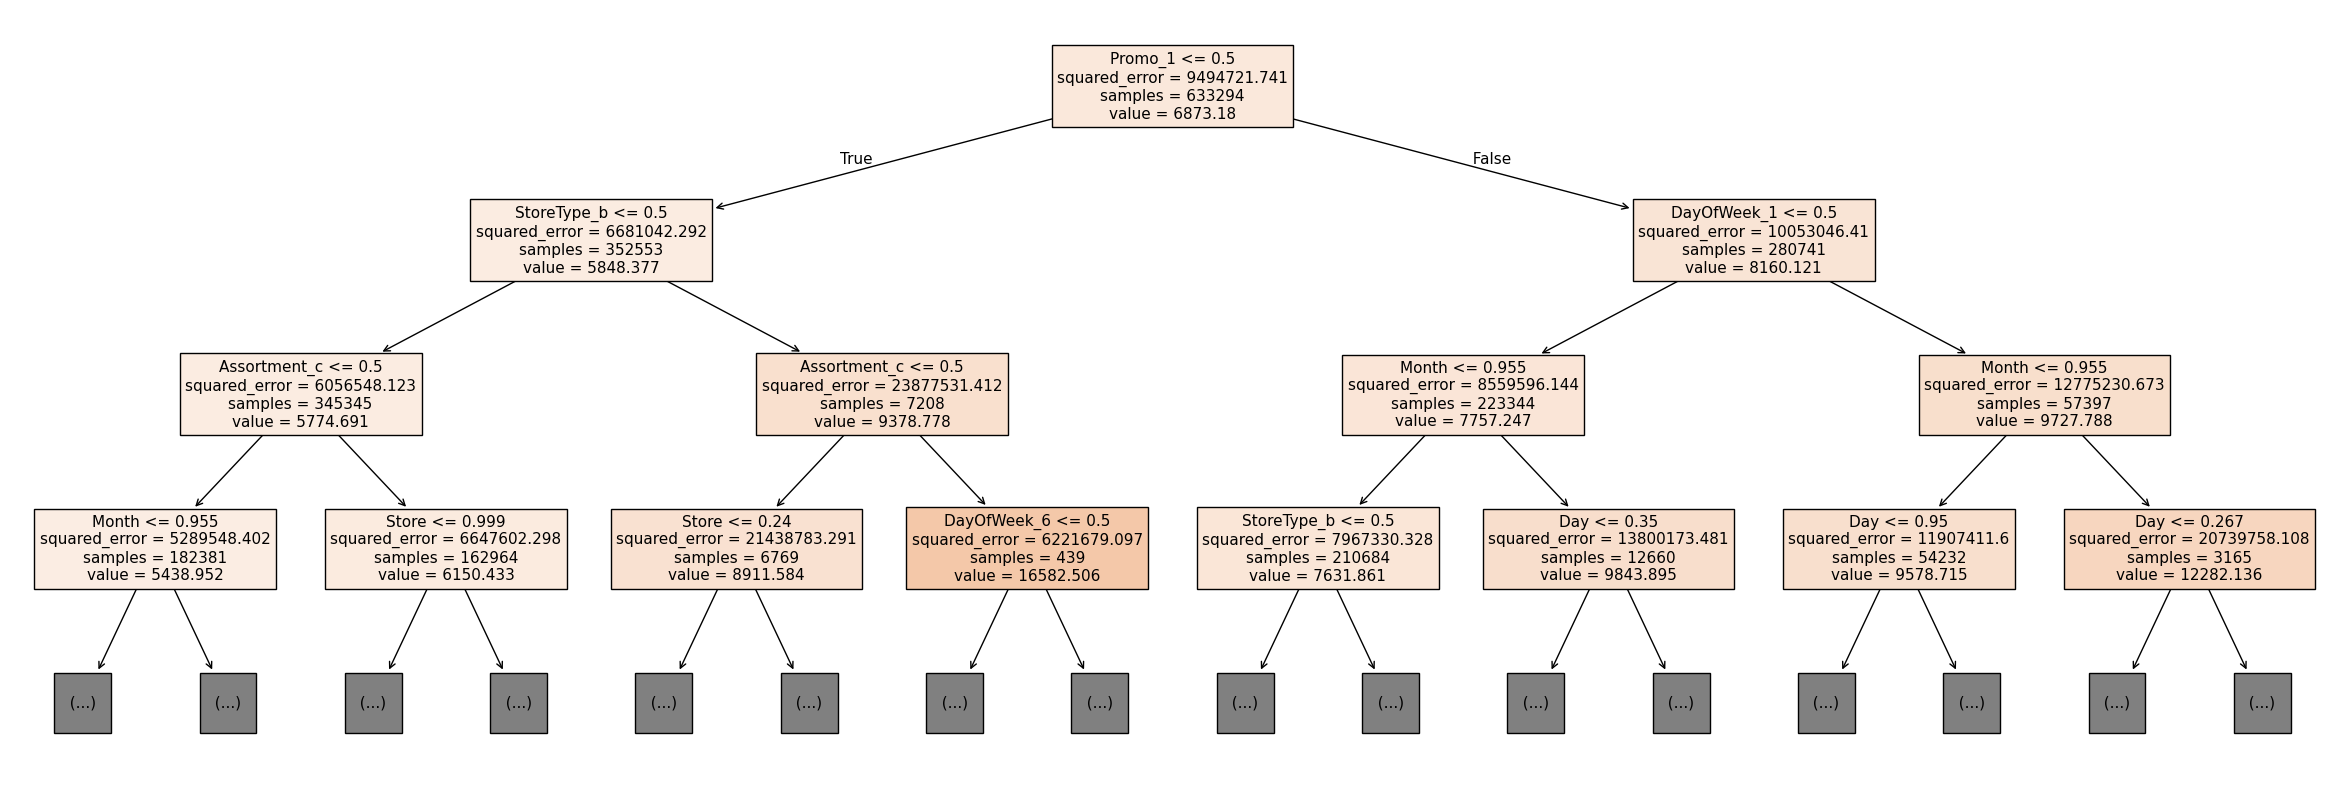

In [101]:
plt.figure(figsize=(30, 10))
plot_tree(model, max_depth=3, feature_names=X_test.columns, fontsize=11, filled=True)

In [102]:
#{'train_rmse': 474.38862159017947,
# 'val_rmse': 1373.1518287790345,
# 'train_MAE': 27 6.7373814057926,
# 'val_MAE': 891.8270944300751}
#got these with no hyperparametring max_depth = 61, n_estimators=100
rf = RandomForestRegressor(random_state=54, 
                                n_jobs=-1, 
                                verbose=1,
                                max_depth=35,
                                n_estimators=50)

#try_model(rf)

In [103]:
rf.fit(X_train, train_targets)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   31.0s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",35
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [104]:
train_preds = rf.predict(X_train)
train_preds

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.8s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    2.8s finished


array([7801.3       , 7465.1       , 9150.06      , ..., 7876.54      ,
       5287.76      , 4301.58000971], shape=(633294,))

In [105]:
val_preds = rf.predict(X_val)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.6s finished


In [106]:
#{'train_rmse': 474.38862159017947,
# 'val_rmse': 1373.1518287790345,
# 'train_MAE': 276.7373814057926,
# 'val_MAE': 891.8270944300751}
#got these with no hyperparametring max_depth = 61, n_estimators=100

# {'train_rmse': 2653.3090582834557,
#  'val_rmse': 2749.2800054500794,
#  'train_MAE': 1933.8799341902468,
#  'val_MAE': 1974.3075079800549} 
# got these with hyperparametring max_depth = 5, n_estimators=100, 

# {'train_rmse': 1540.8604575650572,
#  'val_rmse': 1870.741508104508,
#  'train_MAE': 1100.967198159111,
#  'val_MAE': 1317.8665562646192}
# got these with hyperparametring max_depth = 20 n_estimators=200, 

# {'train_rmse': 2586.739852123099,
#  'val_rmse': 2697.277778078929,
#  'train_MAE': 1886.3848525999388,
#  'val_MAE': 1941.6626065484197}
# got these with hyperparametring max_depth=30, n_estimators=200, max_leaf_nodes=50, min_samples_split=15, min_impurity_decrease=1e-6

# {'train_rmse': 500.279245642747,
#  'val_rmse': 1373.4069596016332,
#  'train_MAE': 305.92269798126586,
#  'val_MAE': 892.0359197229307}
# got these with hyperparametring max_depth=35, n_estimators=150, max_leaf_nodes=50, min_samples_split=15, min_impurity_decrease=1e-6

# {'train_rmse': 512.7453573969325,
#  'val_rmse': 1379.1611840541002,
#  'train_MAE': 311.5018979475749,
#  'val_MAE': 896.6415663468015}
# got these with hyperparametring max_depth=35, n_estimators=50

# Step-10: Experiment and Combine Results from Multiple Stregeries
***Regularization & Ensembling***

In general, the following strategies can be used to improve the performance of a model:

1. Gather more data. A greater amount of data can let you learn more relationships and generalize the model better.
2. Include more features. The more relevant the features for predicting the target, the better the model gets.
3. Tune the hyperparameters of the model. Increase the capacity of the model while ensuring that it doesn't overfit.
4. Look at the specific examples where the model make incorrect or bad predictions and gather some insights
5. Try strategies like **grid search** for hyperparameter optimization and **K-fold cross validation**
6. *Combine results from different types of models (ensembling), or train another model using their results.*

**Hyperparameter Optimization & Grid Search**

You can tune hyperparameters manually, our use an automated tuning strategy like random search or Grid search. Follow this tutorial for hyperparameter tuning using Grid search: https://machinelearningmastery.com/hyperparameter-optimization-with-random-search-and-grid-search/

**K-Fold Cross Validation**

Here's what K-fold cross validation looks like visually (source):

Follow this tutorial to apply K-fold cross validation: https://machinelearningmastery.com/repeated-k-fold-cross-validation-with-python/

**Ensembling and Stacking**

Ensembling refers to combining the results of multiple models.

Stacking is a more advanced version of ensembling, where we train another model using the results from multiple models.a

# Step-11: Interpret Models, Study Individual Predictions & Present Your Findings

**Feature Importance**

You'll need to explain why your model returns a particular result. Most scikit-learn models offer some kind of "feature importance" score.

In [107]:
X_train.columns

Index(['Store', 'Day', 'Month', 'Year', 'DayOfWeek_1', 'DayOfWeek_2',
       'DayOfWeek_3', 'DayOfWeek_4', 'DayOfWeek_5', 'DayOfWeek_6',
       'DayOfWeek_7', 'Promo_0', 'Promo_1', 'StateHoliday_0', 'StateHoliday_a',
       'StateHoliday_b', 'StateHoliday_c', 'StoreType_a', 'StoreType_b',
       'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b',
       'Assortment_c'],
      dtype='object')

In [108]:
rf.feature_importances_

array([6.09037077e-01, 4.80754618e-02, 4.64057275e-02, 9.17848929e-03,
       3.38326104e-02, 4.33880444e-03, 2.34486171e-03, 2.03102577e-03,
       5.73331947e-03, 6.75011979e-03, 4.45197883e-03, 5.58885199e-02,
       8.40943361e-02, 1.14875957e-03, 2.15420953e-04, 2.86914489e-05,
       2.29913255e-05, 1.32696285e-02, 2.27598977e-02, 1.02043743e-02,
       1.36884532e-02, 8.00809352e-03, 5.52719189e-03, 1.29641654e-02])

In [109]:
importance_df = pd.DataFrame({
    'columns': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

<Axes: xlabel='importance', ylabel='columns'>

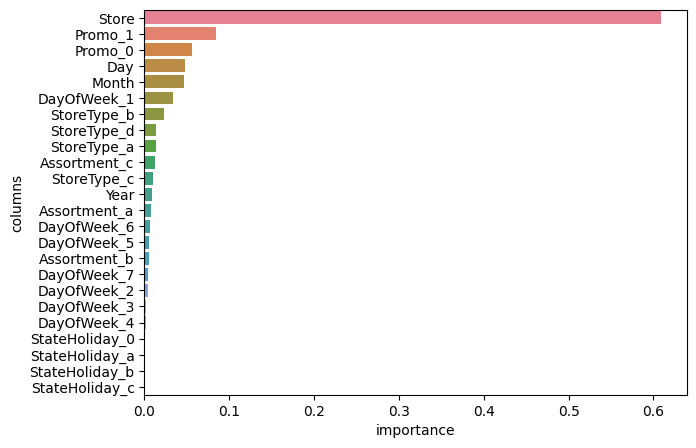

In [110]:
plt.figure(figsize=(7, 5))
sns.barplot(data=importance_df, x='importance', y='columns', hue="columns")

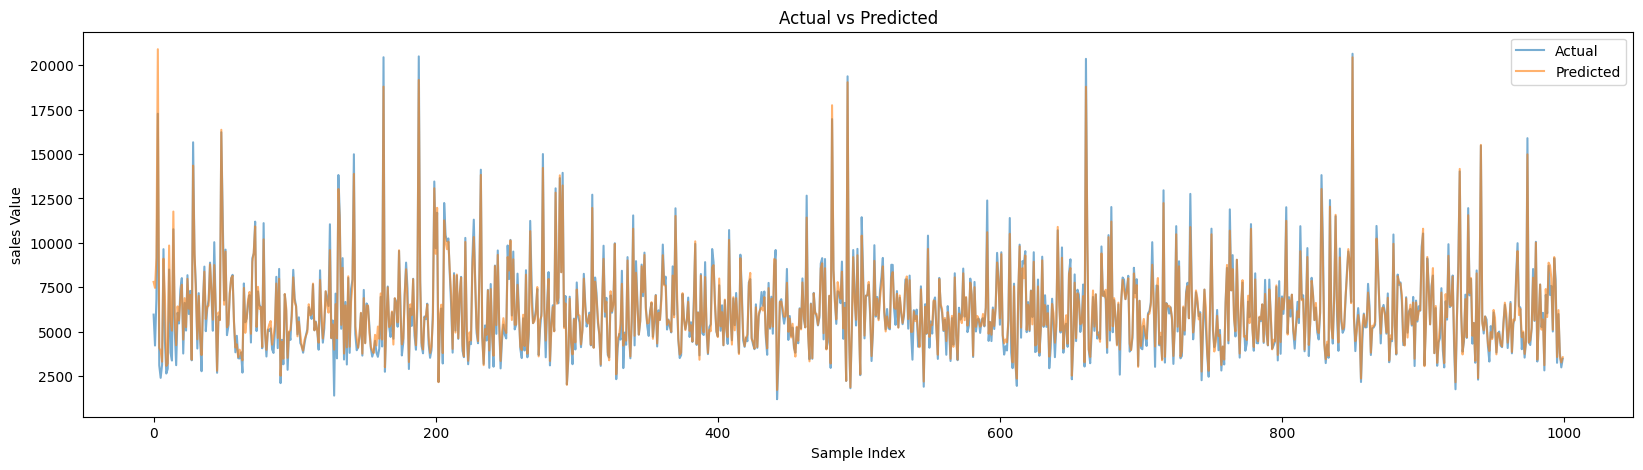

In [111]:
x = np.arange(len(train_targets))   # SAME x-axis

plt.figure(figsize=(20, 5))
plt.plot(x[:1000], train_targets[:1000], label='Actual', alpha=0.6)
plt.plot(x[:1000], train_preds[:1000], label='Predicted', alpha =0.6)

plt.xlabel('Sample Index')
plt.ylabel('sales Value')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

In [112]:
actual_preds_df = pd.DataFrame({
    'Index': range(len(train_targets)),
    'Actual': train_targets,
    'Predicted': train_preds
})

In [113]:
fig = px.line(
    actual_preds_df[:5000],
    x='Index',
    y=['Actual', 'Predicted'],
    labels={'value': 'Value', 'variable': 'Type'}
)
fig.update_layout(width=1200, height=500, hovermode='x unified')
fig.update_traces(opacity=0.6)
fig.show()

In [114]:
fig = px.line(x=range(len(train_targets[:2000])), y=[list(train_targets[:2000]), list(train_preds[:2000])], labels={'value':'Sales value', 'variable':'type'})
fig.update_traces(opacity=0.4)
fig.update_layout(hovermode='x unified')